## 🧠 What is Self-Reflection(自我反思) in RAG?
Self-reflection = LLM evaluates its own output:
“Is this clear, complete, and accurate?”

#### Self-Reflection in RAG using LangGraph, we’ll design a workflow where the agent:

1. Generates an initial answer using retrieved context
2. Reflects on that answer with a dedicated self-critic LLM step
3. If unsatisfied, it can revise the query, retrieve again, or regenerate the answer

In [14]:
import os
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["OPENAI_BASE_URL"] = os.getenv("OPENAI_BASE_URL")
llm = init_chat_model("openai:gpt-4o")

In [15]:
from typing import List
from pydantic import BaseModel
from langchain_classic.schema import Document
from langchain_openai import OpenAIEmbeddings
from langchain_community.document_loaders import TextLoader
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import StateGraph, START, END

In [16]:
# -------------------------------
# 1. Prepare Vectorstore
# -------------------------------
docs = TextLoader("research_notes.txt", encoding="utf-8").load()
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
chunks = splitter.split_documents(docs)
embedding = OpenAIEmbeddings()
vectorstore = FAISS.from_documents(chunks, embedding)
retriever = vectorstore.as_retriever()

In [17]:
# -------------------------
# 2. State Definition
# -------------------------
class RAGReflectionState(BaseModel):
    question: str
    retrieved_documents: List[Document] = []
    answer: str = ""
    reflection: str = ""
    revised: bool = False
    attempts: int = 0

In [18]:
# -------------------------
# 3. Nodes
# -------------------------

# a. Retrieve
def retrieve_docs(state: RAGReflectionState) -> RAGReflectionState:
    print("---------- Retrieving -----------")
    results = retriever.invoke(state.question)
    return state.model_copy(update={"retrieved_documents": results})

# b. Generate Answer
def generate_answer(state: RAGReflectionState) -> RAGReflectionState:
    print("---------- Generating Answer -----------")
    context = [doc.page_content for doc in state.retrieved_documents]
    prompt = f"""
Use the following context to answer the question:

Context:
{context}

Question:
{state.question}
"""
    result = llm.invoke(prompt).content.strip()
    return state.model_copy(update={"answer": result, "attempts": state.attempts + 1})

In [19]:
# c. Self-Reflect
def reflect_on_answer(state: RAGReflectionState) -> RAGReflectionState:
    print("---------- Reflecting on Answer -----------")
    prompt = f"""
Reflect on the following answer to see if it fully addresses the question. 
State YES if it is complete and correct, or NO with an explanation.

Question: {state.question}

Answer: {state.answer}

Respond like:
Reflection: YES or NO
Explanation: ...
"""
    result = llm.invoke(prompt).content.strip()
    is_ok = "yes" in result.lower()
    return state.model_copy(update={"reflection": result, "revised": not is_ok})

In [20]:
# d. Finalizer
def finalize(state: RAGReflectionState) -> RAGReflectionState:
    print(f"Finalizing state with {state.attempts} attempts")
    return state

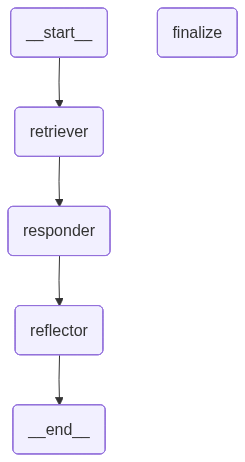

In [21]:
builder = StateGraph(RAGReflectionState)

builder.add_node("retriever", retrieve_docs)
builder.add_node("responder", generate_answer)
builder.add_node("reflector", reflect_on_answer)
builder.add_node("finalize", finalize)

builder.add_edge(START, "retriever")
builder.add_edge("retriever", "responder")
builder.add_edge("responder", "reflector")
builder.add_conditional_edges(
    "reflector",
    lambda state: "finalize" if not state.revised or state.attempts >= 3 else "retriever"
)
builder.add_edge("finalize", END)

graph = builder.compile()
graph

In [22]:
# -------------------------
# 5. Run the Agent
# -------------------------
if __name__ == "__main__":
    user_query = "what are the additional eperiments in Transformer eveluation?"
    init_state = RAGReflectionState(question=user_query)
    result = graph.invoke(init_state)

    print("\n🧠 Final Answer:\n", result["answer"])
    print("\n🔁 Reflection Log:\n", result["reflection"])
    print("🔄 Total Attempts:", result["attempts"])

---------- Retrieving -----------
---------- Generating Answer -----------
---------- Reflecting on Answer -----------
---------- Retrieving -----------
---------- Generating Answer -----------
---------- Reflecting on Answer -----------
---------- Retrieving -----------
---------- Generating Answer -----------
---------- Reflecting on Answer -----------
Finalizing state with 3 attempts

🧠 Final Answer:
 The additional experiments in the Transformer evaluation are as follows:

1. FlashAttention2:
   - Integrated into LLaMA2
   - Reduces context latency by ~50%

2. Chain-of-Thought Prompting:
   - Outperforms direct answer prompting by 8% on logic tasks
   - Reflective prompting increases accuracy by 3%

5. Retrieval Experiments:
   - Hybrid dense + sparse retriever
   - Tested Weaviate vs FAISS + BM25 reranking
   - FAISS is more efficient but has slightly lower recall
   - Weaviate integration with GraphQL helpful for filtering

6. LoRA Tuning:
   - Used for adapter-based fine-tuning
